# Bloch Boundary Conditions in FDTDX

This notebook is a self-contained tutorial on **Bloch boundary conditions**: what they are, why FDTD simulations need them, and how to use them in [FDTDX](https://fdtdx.readthedocs.io/en/latest/) (a JAX-based FDTD package).

We'll build a small, concrete example:

- a **cubic** simulation volume,
- a **plane-wave source** spanning the full top `xy`-plane, injected at **45° angle of incidence**,
- **PML** absorbing boundaries on top/bottom (`z`),
- **Bloch boundary conditions** on all four side walls, with the Bloch vector set to match the source's tilt,
- an **energy detector** that records a video of the fields as the simulation runs.

Along the way we'll also cover the connection between Bloch boundaries and **photonic band-structure calculations**, since that is their other major use case.

## 1. What is a Bloch boundary condition?

In any FDTD simulation, the simulation volume is finite, so every boundary needs a rule for what happens to the fields once they reach the edge. The three boundary types relevant here are:

- **PML (perfectly matched layer):** an absorbing layer that lets outgoing waves leave without reflecting back in. Used for boundaries that represent "open space."
- **Periodic:** the field that leaves through one face is copied straight back in on the opposite face, `F(x + L) = F(x)`. This models an infinitely repeating structure, but only correctly if the *fields themselves* are exactly periodic with period `L`.
- **Bloch:** the same idea as periodic, but with a complex phase factor tacked on:

$$
F(\mathbf{r} + \mathbf{L}) = F(\mathbf{r})\, e^{\,i\, \mathbf{k}_{\text{Bloch}} \cdot \mathbf{L}}
$$

where $\mathbf{L}$ is the lattice/domain vector connecting the two opposite faces and $\mathbf{k}_{\text{Bloch}}$ is a **Bloch wave vector** you choose. Setting $\mathbf{k}_{\text{Bloch}} = 0$ recovers an ordinary periodic boundary — so Bloch boundaries are a strict generalization of periodic ones.

### Why the phase factor is needed

This form comes directly from **Bloch's theorem**: for a periodic medium, every eigenmode of the system can be written as a plane wave times a function with the same periodicity as the medium,

$$
E_{\mathbf n,\mathbf k}(\mathbf r) = u_{\mathbf n,\mathbf k}(\mathbf r)\, e^{i \mathbf k \cdot \mathbf r}, \qquad u_{\mathbf n, \mathbf k}(\mathbf r + \mathbf L) = u_{\mathbf n,\mathbf k}(\mathbf r).
$$

Because $u$ is exactly periodic but the plane-wave envelope is not, the *full* field acquires the phase factor $e^{i\mathbf k \cdot \mathbf L}$ every time you shift by one period $\mathbf L$ — exactly the relation the Bloch boundary enforces.

### The practical trigger: a tilted plane wave

The most common situation where you *must* use Bloch boundaries instead of plain periodic ones is illuminating a periodic structure with a plane wave at an angle. A plane wave with in-plane wave vector $\mathbf k_\parallel \ne 0$ (i.e. anything other than normal incidence) does **not** repeat exactly every period — its phase keeps advancing by $\mathbf k_\parallel \cdot \mathbf L$ from one period to the next. If you used an ordinary periodic boundary here, you'd be forcing the field to snap back to zero phase shift at the edge, which is physically wrong and shows up as spurious scattering/artifacts right at the boundary. A Bloch boundary with $\mathbf k_{\text{Bloch}} = \mathbf k_\parallel$ fixes this: the boundary now enforces exactly the phase advance the tilted wave actually has, so the simulation behaves as if it were one cell cut out of an infinite, uniformly tilted plane wave.

This is exactly the situation we'll simulate below — a single "unit cell" of free space illuminated by a plane wave tilted 45° from normal, using Bloch boundaries on the sides so the tilt is handled correctly.


## 2. Bloch boundaries and band-structure calculations

The angled-illumination example above uses a **single frequency** and a **single, fixed** Bloch vector — but Bloch boundaries are also the fundamental building block for computing a **photonic band structure** (the dispersion relation $\omega_n(\mathbf k)$ of a periodic structure, e.g. a photonic crystal).

The recipe looks like this:

1. **Model one unit cell** of the periodic structure (e.g. one period of a hole array, one layer of a stack), with **Bloch boundaries on every periodic direction** and PML (or another open boundary) on any non-periodic direction — structurally identical to the setup in this notebook.
2. **Excite it broadband.** Instead of a single-frequency continuous-wave source, use a short pulse (or several randomly placed point-dipole sources) so that many modes get excited at once.
3. **Record a time signal** with a field detector at one or a few points inside the cell.
4. **Fourier-transform (or harmonic-invert) the recorded signal.** Every Bloch mode that exists at that particular $\mathbf k$ shows up as a sharp resonance peak in the spectrum — that peak's frequency is an eigenfrequency $\omega_n(\mathbf k)$ of the structure at that $\mathbf k$.
5. **Sweep $\mathbf k_{\text{Bloch}}$** along the edges of the irreducible Brillouin zone (for a 2D square lattice, the classic path is $\Gamma \to X \to M \to \Gamma$) and repeat steps 2–4 at each point.
6. **Plot all the extracted $\omega_n(\mathbf k)$ against $\mathbf k$** — that is the band diagram.

The angled-plane-wave demo below is a good way to build intuition for step 1 precisely because it uses the *same* `fdtdx.BlochBoundary` machinery, just with the Bloch vector coming from a source's incidence angle rather than from a Brillouin-zone sweep.

With the theory covered, let's build the simulation.


## 3. Building the simulation

### 3.1 Imports


In [51]:
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video

import fdtdx
from fdtdx.core.linalg import get_wave_vector_raw, rotate_vector

%matplotlib inline

### 3.2 Simulation config and the cubic volume

We use a single free-space wavelength of 1.55 µm and a cubic simulation volume (equal side length in `x`, `y`, `z`).


In [54]:
key = jax.random.PRNGKey(42)
object_list = []

wavelength = 1.55e-6          # free-space wavelength
angle_of_incidence_deg = 45.0  # angle of incidence, measured from the surface normal (z-axis)

config = fdtdx.SimulationConfig(
    time=60e-15,
    grid=fdtdx.UniformGrid(spacing=100e-9),
    dtype=jnp.float32,
    courant_factor=0.99,
)

L = 6.0e-6  # cubic volume: same side length along x, y, and z
volume = fdtdx.SimulationVolume(
    partial_real_shape=(L, L, L),
    material=fdtdx.Material(  # background material (vacuum)
        permittivity=1.0,
        permeability=1.0,
    ),
)
object_list.append(volume)

constraints = []


### 3.3 Setting the Bloch vector from the source angle

FDTDX's plane-wave sources are tilted using an `azimuth_angle` / `elevation_angle` pair, and the mapping from those angles to the actual propagation direction (and hence to the transverse wave vector $\mathbf k_\parallel$ you need for the Bloch boundary) is **not** the "textbook" spherical convention you might expect (azimuth = rotation around the propagation axis, elevation = polar angle from it). Instead, for a source lying in the `xy`-plane (`horizontal_axis = x`, `vertical_axis = y`, `propagation_axis = z`):

- `azimuth_angle` alone tilts the propagation direction within the **`x`–`z`** plane,
- `elevation_angle` alone tilts it within the **`y`–`z`** plane,
- and the two do *not* simply compose like a standard yaw/pitch — mixing both angles gives a direction that isn't simply "azimuth around `z`, then elevation away from `z`."

We set **`elevation_angle = 0`** and use **`azimuth_angle`** as our single angle of incidence (a clean tilt confined to the `x`–`z` plane). This guarantees the Bloch vector we compute always matches what the source injects.


In [57]:
theta = np.deg2rad(angle_of_incidence_deg)

propagation_axis = 2  # z: the source lies in the xy-plane
horizontal_axis, vertical_axis = 0, 1  # x, y

wave_vector_raw = get_wave_vector_raw(
    direction="-",              # propagating downward, -z
    propagation_axis=propagation_axis,
    dtype=jnp.float32,
)
wave_vector_dir = rotate_vector(
    wave_vector_raw,
    azimuth_angle=theta,     # our angle of incidence
    elevation_angle=0.0,     # keep the tilt confined to the x-z plane
    axes_tuple=(horizontal_axis, vertical_axis, propagation_axis),
)
wave_vector_dir = np.asarray(wave_vector_dir)
print("unit propagation direction (x, y, z):", np.round(wave_vector_dir, 4))

k0 = 2 * np.pi / wavelength  # free-space wavenumber (background index n=1)
bloch_vector = tuple(k0 * wave_vector_dir)
print("Bloch vector (kx, ky, kz) [rad/m]:", bloch_vector)


unit propagation direction (x, y, z): [-0.7071  0.     -0.7071]
Bloch vector (kx, ky, kz) [rad/m]: (np.float32(-2.866376e+06), np.float32(0.0), np.float32(-2.8663762e+06))


Only the `x` and `y` components of `bloch_vector` matter here, since those are the axes that will actually use Bloch boundaries below — `z` uses PML, so its Bloch component is unused (`BlochBoundary` only reads the component along its own axis).

### 3.4 Boundaries: Bloch on the sides, PML on top/bottom

`fdtdx.BoundaryConfig.from_uniform_bound` sets one boundary type on all six faces by default and lets us override specific ones — exactly what we need: `"bloch"` everywhere, overridden to `"pml"` on `min_z`/`max_z`.


In [61]:
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(
    thickness=10,
    boundary_type="bloch",
    override_types={"min_z": "pml", "max_z": "pml"},
    bloch_vector=bloch_vector,
)
bound_dict, c_list = fdtdx.boundary_objects_from_config(bound_cfg, volume)
object_list.extend(bound_dict.values())
constraints.extend(c_list)


### 3.5 The tilted plane-wave source

A `UniformPlaneSource` gives a spatially uniform plane wave (as opposed to `GaussianPlaneSource`, which has a finite spot size). We place it at the top of the volume, spanning the full `xy`-plane, and give it the same angle of incidence we used to compute the Bloch vector.


In [64]:
source = fdtdx.UniformPlaneSource(
    partial_grid_shape=(None, None, 1),   # a single-cell-thick plane...
    fixed_E_polarization_vector=(1, 0, 0),  # ...Ex-polarized...
    wave_character=fdtdx.WaveCharacter(wavelength=wavelength),
    direction="-",                         # ...propagating downward...
    azimuth_angle=angle_of_incidence_deg,  # ...tilted 45 deg in the x-z plane
    elevation_angle=0.0,
)
object_list.append(source)
constraints.extend(
    [
        source.place_relative_to(
            volume,
            axes=(0, 1, 2),
            own_positions=(0, 0, 1),
            other_positions=(0, 0, 1),
            margins=(0, 0, -0.75e-6),  # just inside the top PML
        ),
        source.same_size(volume, axes=(0, 1)),  # spans the full xy plane
    ]
)


### 3.6 A small scatterer, for a more interesting video

Pure free space would just show a tilted, featureless plane wave sweeping through. We drop a small dielectric cube in the middle so the video shows some actual scattering, while still cleanly demonstrating that the Bloch side walls handle the 45° tilt without artifacts.


In [67]:
cube = fdtdx.UniformMaterialObject(
    partial_real_shape=(1.5e-6, 1.5e-6, 1.5e-6),
    material=fdtdx.Material(permittivity=4.0),  # n ~ 2, e.g. a dielectric like Si3N4/TiO2
    name="Cube",
    color=fdtdx.colors.PINK,
)
object_list.append(cube)
constraints.append(cube.place_at_center(volume))


### 3.7 The video detector

An `EnergyDetector` with `as_slices=True` records 2D field-energy slices at regular intervals, which `draw_plot()` later turns into a video.


In [70]:
video_energy_detector = fdtdx.EnergyDetector(
    name="Video",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=4),  # record every 4th time step
    exact_interpolation=True,
    num_video_workers=4,
)
object_list.append(video_energy_detector)
constraints.extend(video_energy_detector.same_position_and_size(volume))


### 3.8 Resolve the placement and inspect the geometry

`fdtdx.place_objects` resolves every constraint into concrete grid positions.


In [73]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

print("field dtype (should be complex since the Bloch vector != 0):", arrays.fields.E.dtype)
print("grid shape (x, y, z):", arrays.fields.E.shape[1:])


field dtype (should be complex since the Bloch vector != 0): complex64
grid shape (x, y, z): (60, 60, 60)


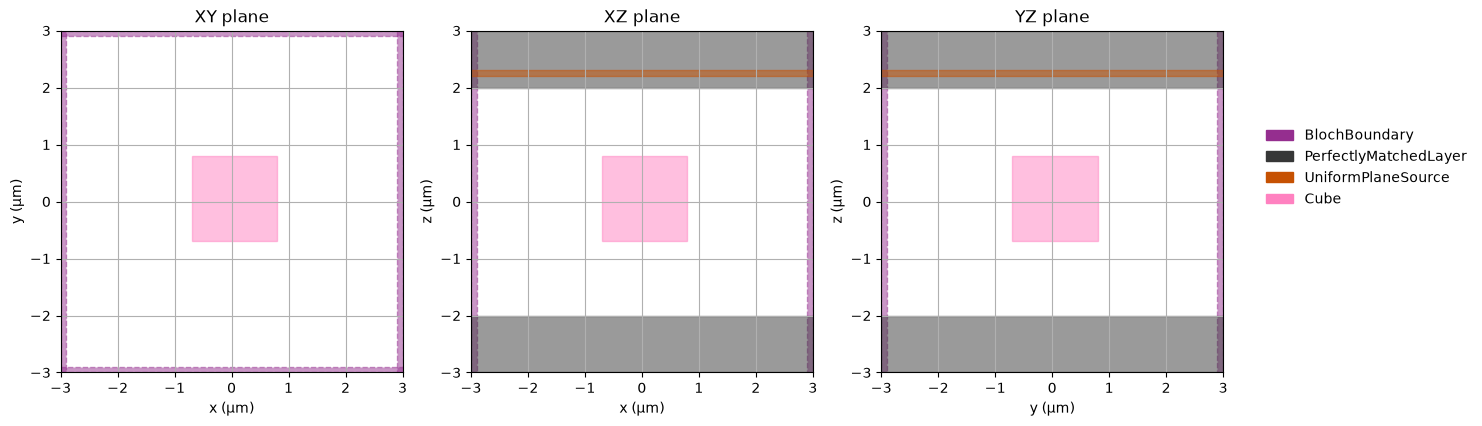

In [75]:
fig = fdtdx.plot_setup(
    config=config,
    objects=objects,
    exclude_object_list=[video_energy_detector],
)
plt.show()


### 3.9 Run the FDTD simulation

As usual in fdtdx, we `jax.jit` the combination of `apply_params` (which finalizes any parametric objects) and `run_fdtd` (the actual time-stepping loop).


In [78]:
def sim_fn(params, arrays, key):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
    )
    _, arrays = final_state
    return arrays


start_time = time.time()
jitted_sim_fn = jax.jit(sim_fn).lower(params, arrays, key).compile()
end_time = time.time()
print(f"Compilation time: {end_time - start_time:.2f} s")


Compilation time: 0.27 s


In [80]:
start_time = time.time()
new_arrays = jitted_sim_fn(params, arrays, subkey)
end_time = time.time()
print(f"Simulation runtime: {end_time - start_time:.2f} s")


FDTD (checkpointed):   0%|                            | 0/315 [00:00<?, ?step/s]

Simulation runtime: 0.59 s


FDTD (checkpointed):  44%|████▍     | 140/315 [00:03<00:03, 45.93step/s]

FDTD (checkpointed):  51%|█████     | 160/315 [00:03<00:03, 46.49step/s]

FDTD (checkpointed):  57%|█████▋    | 180/315 [00:03<00:02, 46.95step/s]

...

FDTD (checkpointed):  89%|████████▉ | 280/315 [00:05<00:00, 48.17step/s]

FDTD (checkpointed):  95%|█████████▌| 300/315 [00:06<00:00, 48.29step/s]

FDTD (checkpointed): 100%|██████████| 315/315 [00:06<00:00, 48.36step/s]

FDTD (checkpointed): 100%|██████████| 315/315 [00:06<00:00, 48.34step/s]

Simulation runtime: 7.01 s


## 4. Watch the result

`draw_plot` renders the recorded energy slices into a video. You should see a plane wave sweeping in at 45°, interacting with the dielectric cube, with **no visible artifacts at the side walls** — that's the Bloch boundary correctly propagating the tilted wavefronts across the periodic boundary.


In [83]:
video_path = objects["Video"].draw_plot(new_arrays.detector_states["Video"])
print(video_path)
Video(list(video_path.values())[0], embed=True, width=720)


{'sliced_video': '/var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/tmpdcic3iri.mp4'}
